# GeoCebada — cobertura y alineación temporal

Esta notebook estudia cuándo tenemos observaciones satelitales para cada parcela y transforma las capturas irregulares de BASIC/PRO a una rejilla temporal común.

La idea es: `capturas irregulares → k vecinos temporales → curva alineada → features comparables entre parcelas`. Cada variable elige sus propias fechas válidas más cercanas.

No se usan los targets ocultos de `PREDICCION`.

> El target corresponde al ciclo abril–octubre de 2025, pero el cutoff operacional exacto para una predicción pre-cosecha todavía debe fijarse. Usar todo abril–octubre aquí es exploratorio.


## 0. Entorno

La siguiente celda localiza el root e instala GeoCebada en modo editable. En una computadora normal deja `INSTALL_GPU_EXTRA = False`. En el servidor NVIDIA/CUDA puedes cambiarlo a `True`.


In [1]:
import subprocess
import sys
from pathlib import Path


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        has_project = (candidate / "pyproject.toml").exists()
        has_package = (candidate / "src" / "geocebada").exists()
        if has_project and has_package:
            return candidate
    raise RuntimeError(
        "No se encontró GeoCebada. Abre Jupyter desde dentro del repositorio."
    )


ROOT = find_repo_root()
INSTALL_GPU_EXTRA = False
extras = "dev,geo,gpu" if INSTALL_GPU_EXTRA else "dev,geo"
package_spec = f"{ROOT}[{extras}]"
subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-e", package_spec]
)
print(f"Repositorio: {ROOT}")
print(f"Python: {sys.version.split()[0]}")


Repositorio: C:\Users\herie\OneDrive - Fundacion Universidad de las Americas Puebla\GeoCebada
Python: 3.11.16


In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from geocebada.data import (
    attach_yield_split_metadata,
    load_basic_data,
    load_pro_data,
    load_yield_split,
)
from geocebada.features import (
    align_temporal_knn,
    aligned_to_wide,
    make_temporal_grid,
    temporal_backend_available,
    temporal_coverage_summary,
)

pd.set_option("display.max_columns", 30)
print("Backend temporal detectado:", temporal_backend_available("auto"))


Backend temporal detectado: cpu


## 1. Configuración

Por defecto alineamos sólo `*_promedio`. Cambia `USE_ALL_INDEX_STATS = True` para incluir también `std`, `min` y `max`.

La configuración inicial usa una rejilla de 14 días, `k=3`, ancho temporal de 14 días, distancia máxima de 30 días y ponderación por nubosidad. `BACKEND="auto"` usa GPU si CuPy/CUDA está disponible.


In [3]:
SOURCE = "BASIC"
START_DATE = "2025-04-01"
END_DATE = "2025-10-31"
GRID_FREQ = "14D"
K = 3
BANDWIDTH_DAYS = 14.0
MAX_DISTANCE_DAYS = 30.0
CLOUD_WEIGHTING = True
BACKEND = "auto"
USE_ALL_INDEX_STATS = False
RANDOM_SEED = 42


## 2. Cargar BASIC o PRO

Una fila es aproximadamente `parcela × fecha × sensor`; no es una muestra independiente de rendimiento.


In [4]:
if SOURCE.upper() == "BASIC":
    data = load_basic_data(attach_split=True)
elif SOURCE.upper() == "PRO":
    data = load_pro_data(attach_split=True)
else:
    raise ValueError("SOURCE debe ser 'BASIC' o 'PRO'.")

data["fecha_captura"] = pd.to_datetime(
    data["fecha_captura"], errors="coerce"
)
print("Shape:", data.shape)
print("Parcelas:", data["ID_POLIGONO"].nunique())
print("Sensores:", sorted(data["sensor"].dropna().astype(str).unique()))
print("Fechas:", data["fecha_captura"].min(), "→", data["fecha_captura"].max())
display(data.head())


Shape: (107666, 99)
Parcelas: 197
Sensores: ['Landsat', 'Sentinel-2']
Fechas: 2022-01-01 00:00:00 → 2025-12-31 00:00:00


C:\Users\herie\AppData\Local\Temp\ipykernel_46704\3079787886.py:8: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data["fecha_captura"] = pd.to_datetime(


,ID_POLIGONO,fecha_captura,sensor,ndvi_promedio,ndvi_std,ndvi_max,ndvi_min,evi_promedio,evi_std,evi_max,evi_min,crc_promedio,crc_std,crc_max,crc_min,...,dswi5_std,dswi5_max,dswi5_min,nddi_promedio,nddi_std,nddi_max,nddi_min,enddi_promedio,enddi_std,enddi_max,enddi_min,porcentaje_nubosidad,AREA_HA,RENDIMIENTO_T_HA,CONJUNTO
0,AGC_011,2022-04-20,Landsat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,7.17,NaN,PREDICCION
1,AGC_011,2024-03-16,Landsat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,7.17,NaN,PREDICCION
2,AGC_011,2024-03-15,Landsat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,7.17,NaN,PREDICCION
3,AGC_011,2025-08-26,Landsat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,7.17,NaN,PREDICCION
4,AGC_011,2025-03-10,Landsat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,7.17,NaN,PREDICCION


## 3. Cobertura temporal: entrenamiento vs predicción

Aquí sólo inspeccionamos covariables: disponibilidad, gaps y nubosidad. No usamos el rendimiento oculto.


In [5]:
coverage = temporal_coverage_summary(
    data, start=START_DATE, end=END_DATE
)
split = load_yield_split()[["ID_POLIGONO", "CONJUNTO"]]
coverage = coverage.merge(
    split, on="ID_POLIGONO", how="left", validate="many_to_one"
)
display(coverage.head())

summary_columns = [
    column
    for column in [
        "n_records",
        "n_unique_dates",
        "median_gap_days",
        "max_gap_days",
        "cloud_mean",
    ]
    if column in coverage.columns
]
summary = coverage.groupby(
    ["CONJUNTO", "sensor"], dropna=False
)[summary_columns].agg(["mean", "median", "std"])
display(summary.round(2))


,ID_POLIGONO,sensor,n_records,n_unique_dates,first_date,last_date,span_days,median_gap_days,max_gap_days,cloud_mean,cloud_median,n_2025_06,n_2025_09,n_2025_05,n_2025_04,n_2025_08,n_2025_10,n_2025_07,CONJUNTO
0,AGC_001,Landsat,26,26,2025-04-03,2025-10-28,208.0,8.0,16.0,51.940385,74.31,4,4,4,4,4,3,3,ENTRENAMIENTO
1,AGC_001,Sentinel-2,50,50,2025-04-05,2025-10-27,205.0,5.0,10.0,28.076010,0.00,8,6,7,8,7,7,7,ENTRENAMIENTO
2,AGC_002,Landsat,30,30,2025-04-03,2025-10-28,208.0,8.0,15.0,30.965333,0.00,4,4,6,5,4,4,3,ENTRENAMIENTO
3,AGC_002,Sentinel-2,51,51,2025-04-05,2025-10-27,205.0,5.0,10.0,36.259985,0.00,8,7,7,8,7,7,7,ENTRENAMIENTO
4,AGC_003,Landsat,26,26,2025-04-03,2025-10-28,208.0,8.0,16.0,48.532308,30.72,4,4,4,4,4,3,3,PREDICCION


n_records              n_unique_dates               \
                              mean median   std           mean median   std   
CONJUNTO      sensor                                                          
ENTRENAMIENTO Landsat        32.37   26.0  9.96          32.37   26.0  9.96   
              Sentinel-2     50.69   51.0  0.46          50.69   51.0  0.46   
PREDICCION    Landsat        31.24   26.0  9.09          31.24   26.0  9.09   
              Sentinel-2     50.69   51.0  0.46          50.69   51.0  0.46   

                         median_gap_days              max_gap_days         \
                                    mean median   std         mean median   
CONJUNTO      sensor                                                        
ENTRENAMIENTO Landsat               7.43    8.0  1.25        14.44   16.0   
              Sentinel-2            5.00    5.0  0.00        10.00   10.0   
PREDICCION    Landsat               7.44    8.0  1.30        14.85   16.0   
              Sentinel-2            5.00    5.0  0.00        10.00   10.0   

                               cloud_mean               
                           std       mean median   std  
CONJUNTO      sensor                                    
ENTRENAMIENTO Landsat     2.99      38.67  38.80  7.62  
              Sentinel-2  0.00      32.56  32.80  4.95  
PREDICCION    Landsat     2.57      39.32  40.92  7.43  
              Sentinel-2  0.00      32.21  33.14  4.82

### Disponibilidad por semana

Cada celda indica si una parcela tuvo al menos una captura durante esa semana. Las parcelas de predicción aparecen al final de la matriz.


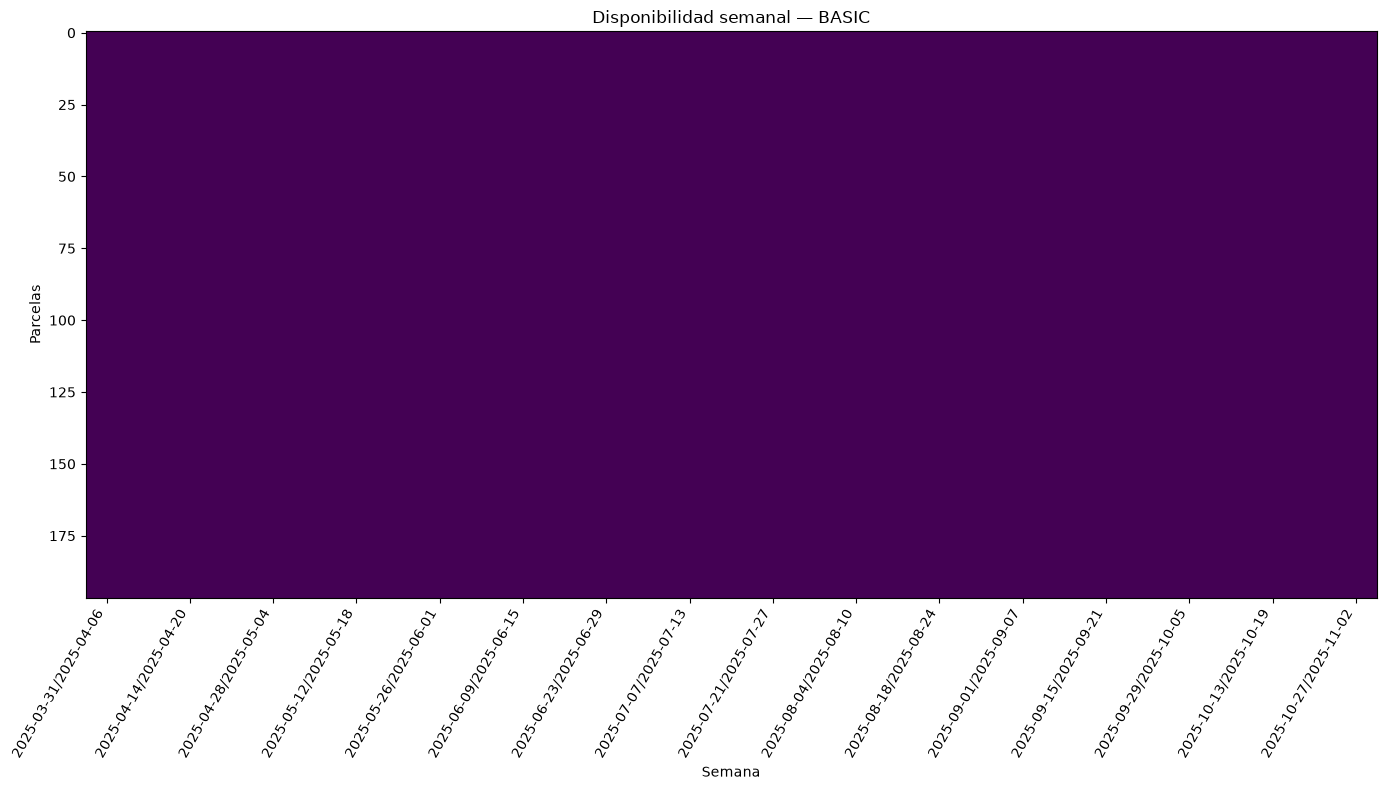

In [6]:
period = data.loc[
    data["fecha_captura"].between(
        START_DATE, END_DATE, inclusive="both"
    ),
    ["ID_POLIGONO", "fecha_captura"],
].dropna()
period["week"] = period["fecha_captura"].dt.to_period("W").astype(str)
availability = (
    pd.crosstab(period["ID_POLIGONO"], period["week"]) > 0
).astype(int)
split_order = split.assign(
    _order=split["CONJUNTO"].map({"ENTRENAMIENTO": 0, "PREDICCION": 1})
)
order = split_order.sort_values(
    ["_order", "ID_POLIGONO"]
)["ID_POLIGONO"]
availability = availability.reindex(order).fillna(0)

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(availability.to_numpy(), aspect="auto", interpolation="nearest")
ax.set_title(f"Disponibilidad semanal — {SOURCE}")
ax.set_xlabel("Semana")
ax.set_ylabel("Parcelas")
step = max(1, availability.shape[1] // 12)
ticks = np.arange(0, availability.shape[1], step)
ax.set_xticks(ticks)
ax.set_xticklabels(
    availability.columns[ticks], rotation=60, ha="right"
)
plt.tight_layout()
plt.show()


## 4. Variables a alinear


In [7]:
metadata = {
    "ID_POLIGONO",
    "fecha_captura",
    "sensor",
    "porcentaje_nubosidad",
    "AREA_HA",
    "RENDIMIENTO_T_HA",
    "CONJUNTO",
}
numeric_candidates = [
    column
    for column in data.select_dtypes(include="number").columns
    if column not in metadata
]
VALUE_COLUMNS = (
    numeric_candidates
    if USE_ALL_INDEX_STATS
    else [
        column
        for column in numeric_candidates
        if column.endswith("_promedio")
    ]
)
print(f"Variables a alinear: {len(VALUE_COLUMNS)}")
print(VALUE_COLUMNS)


Variables a alinear: 23
['ndvi_promedio', 'evi_promedio', 'crc_promedio', 'mcrc_promedio', 'ndsvi_promedio', 'srndi_promedio', 'mra_promedio', 'lai_promedio', 'fapar_promedio', 'savi_promedio', 'vi6t_promedio', 'ndti_promedio', 'sti_promedio', 'ndwi_promedio', 'endwi_promedio', 'msi_promedio', 'emsi_promedio', 'dswi2_promedio', 'dswi3_promedio', 'dswi4_promedio', 'dswi5_promedio', 'nddi_promedio', 'enddi_promedio']


## 5. Alineación k-NN temporal

Para cada fecha objetivo y cada variable se toman sus `K` capturas válidas más cercanas dentro de la misma parcela y sensor. La contribución cae exponencialmente con la distancia y puede penalizarse por nubosidad.


In [8]:
grid = make_temporal_grid(START_DATE, END_DATE, freq=GRID_FREQ)
print("Puntos de rejilla:", len(grid))
print(list(grid.strftime("%Y-%m-%d")))


Puntos de rejilla: 16
['2025-04-01', '2025-04-15', '2025-04-29', '2025-05-13', '2025-05-27', '2025-06-10', '2025-06-24', '2025-07-08', '2025-07-22', '2025-08-05', '2025-08-19', '2025-09-02', '2025-09-16', '2025-09-30', '2025-10-14', '2025-10-28']


In [9]:
start_time = time.perf_counter()
aligned = align_temporal_knn(
    data,
    VALUE_COLUMNS,
    grid=grid,
    start=START_DATE,
    end=END_DATE,
    k=K,
    bandwidth_days=BANDWIDTH_DAYS,
    max_distance_days=MAX_DISTANCE_DAYS,
    cloud_weighting=CLOUD_WEIGHTING,
    backend=BACKEND,
)
elapsed = time.perf_counter() - start_time
used_backend = aligned["backend"].iloc[0] if len(aligned) else "sin filas"
print("Backend usado:", used_backend)
print(f"Tiempo: {elapsed:.2f} s")
print("Shape alineado:", aligned.shape)
display(aligned.head())


Backend usado: cpu
Tiempo: 2.67 s
Shape alineado: (6304, 29)


,ID_POLIGONO,sensor,grid_date,backend,neighbor_count,nearest_gap_days,ndvi_promedio,evi_promedio,crc_promedio,mcrc_promedio,ndsvi_promedio,srndi_promedio,mra_promedio,lai_promedio,fapar_promedio,savi_promedio,vi6t_promedio,ndti_promedio,sti_promedio,ndwi_promedio,endwi_promedio,msi_promedio,emsi_promedio,dswi2_promedio,dswi3_promedio,dswi4_promedio,dswi5_promedio,nddi_promedio,enddi_promedio
0,AGC_001,Landsat,2025-04-01,cpu,3,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.617224,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AGC_001,Landsat,2025-04-15,cpu,3,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.615711,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AGC_001,Landsat,2025-04-29,cpu,3,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.612307,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AGC_001,Landsat,2025-05-13,cpu,3,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.607830,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AGC_001,Landsat,2025-05-27,cpu,3,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.601447,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Diagnóstico de gaps y faltantes


In [10]:
display(
    aligned[["neighbor_count", "nearest_gap_days"]].describe(
        percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
    )
)
missing_pct = (
    aligned[VALUE_COLUMNS]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_pct")
    .to_frame()
)
display(missing_pct.head(30))


,neighbor_count,nearest_gap_days
count,6304.0,6304.000000
mean,3.0,1.647367
std,0.0,1.382049
min,3.0,0.000000
50%,3.0,2.000000
75%,3.0,2.000000
90%,3.0,4.000000
95%,3.0,4.000000
99%,3.0,4.000000
max,3.0,5.000000


,missing_pct
vi6t_promedio,50.015863
evi_promedio,50.000000
ndvi_promedio,50.000000
mcrc_promedio,50.000000
ndsvi_promedio,50.000000
srndi_promedio,50.000000
crc_promedio,50.000000
mra_promedio,50.000000
lai_promedio,50.000000
fapar_promedio,50.000000


## 6. Curvas alineadas de algunas parcelas

Los sensores permanecen separados para no fusionar automáticamente mediciones con calibraciones distintas.


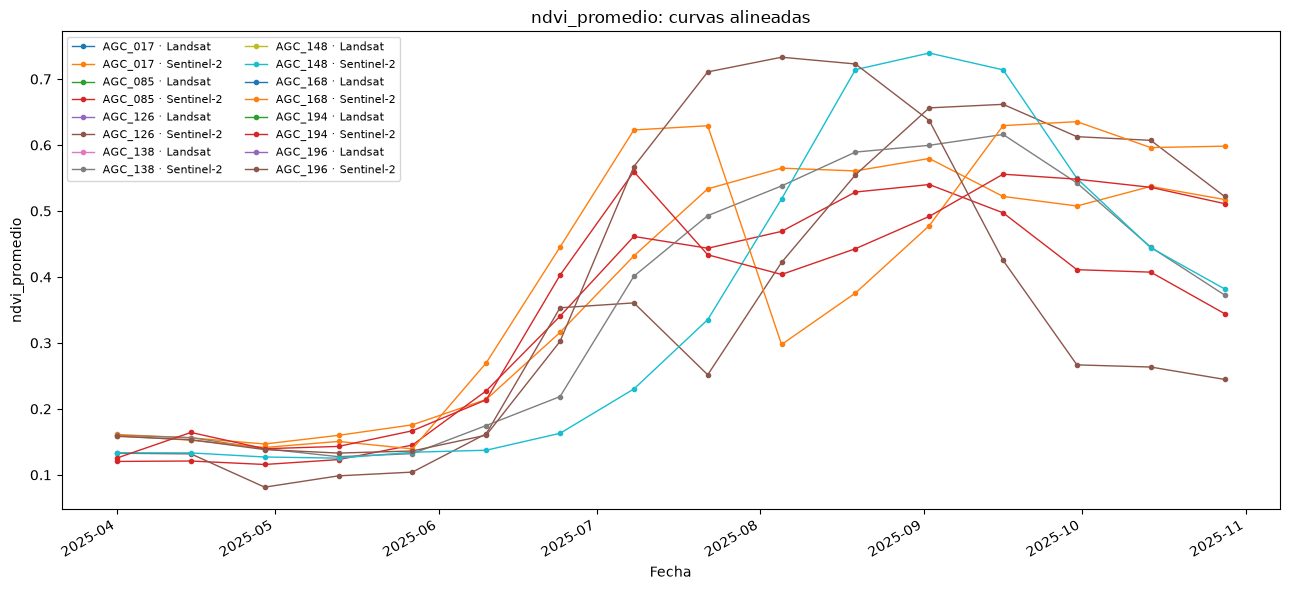

In [11]:
plot_variable = (
    "ndvi_promedio"
    if "ndvi_promedio" in aligned.columns
    else VALUE_COLUMNS[0]
)
rng = np.random.default_rng(RANDOM_SEED)
parcel_ids = aligned["ID_POLIGONO"].drop_duplicates().to_numpy()
sample_ids = rng.choice(
    parcel_ids, size=min(8, len(parcel_ids)), replace=False
)
sample = aligned.loc[aligned["ID_POLIGONO"].isin(sample_ids)]

fig, ax = plt.subplots(figsize=(13, 6))
for (parcel_id, sensor), group in sample.groupby(
    ["ID_POLIGONO", "sensor"], dropna=False
):
    ax.plot(
        group["grid_date"],
        group[plot_variable],
        marker="o",
        linewidth=1,
        markersize=3,
        label=f"{parcel_id} · {sensor}",
    )
ax.set_title(f"{plot_variable}: curvas alineadas")
ax.set_xlabel("Fecha")
ax.set_ylabel(plot_variable)
ax.legend(ncol=2, fontsize=8)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## 7. Una fila por parcela

La tabla `wide` ya tiene una representación temporal comparable por parcela. El sensor queda incluido en cada nombre de feature.


In [12]:
wide = aligned_to_wide(aligned, value_columns=VALUE_COLUMNS)
wide = attach_yield_split_metadata(wide)
print("Shape model-ready temporal:", wide.shape)
print("Parcelas:", wide["ID_POLIGONO"].nunique())
print(
    "Entrenamiento:",
    (wide["CONJUNTO"] == "ENTRENAMIENTO").sum(),
)
print("Predicción:", (wide["CONJUNTO"] == "PREDICCION").sum())
display(wide.iloc[:5, :20])


Shape model-ready temporal: (197, 372)
Parcelas: 197
Entrenamiento: 138
Predicción: 59


,ID_POLIGONO,Sentinel-2__crc_promedio__2025_04_01,Sentinel-2__crc_promedio__2025_04_15,Sentinel-2__crc_promedio__2025_04_29,Sentinel-2__crc_promedio__2025_05_13,Sentinel-2__crc_promedio__2025_05_27,Sentinel-2__crc_promedio__2025_06_10,Sentinel-2__crc_promedio__2025_06_24,Sentinel-2__crc_promedio__2025_07_08,Sentinel-2__crc_promedio__2025_07_22,Sentinel-2__crc_promedio__2025_08_05,Sentinel-2__crc_promedio__2025_08_19,Sentinel-2__crc_promedio__2025_09_02,Sentinel-2__crc_promedio__2025_09_16,Sentinel-2__crc_promedio__2025_09_30,Sentinel-2__crc_promedio__2025_10_14,Sentinel-2__crc_promedio__2025_10_28,Sentinel-2__dswi2_promedio__2025_04_01,Sentinel-2__dswi2_promedio__2025_04_15,Sentinel-2__dswi2_promedio__2025_04_29
0,AGC_001,0.371271,0.373751,0.354239,0.356363,0.279584,0.317761,0.363056,0.320493,0.251764,0.362882,0.346910,0.312773,0.100157,0.010312,0.270554,0.241954,2.005906,2.008420,1.994117
1,AGC_002,0.435480,0.428565,0.408800,0.423310,0.432047,0.227992,0.246296,0.359527,0.368108,0.391689,0.317094,0.288432,0.338344,0.281113,0.302954,0.422533,2.428378,2.390579,2.321288
2,AGC_003,0.486270,0.492670,0.481583,0.477991,0.424485,0.346207,0.317878,0.240718,0.252164,0.298485,0.362919,0.324908,0.093089,0.079737,0.223580,0.387105,2.885246,2.934227,2.888670
3,AGC_004,0.416934,0.416917,0.377890,0.406262,0.339872,0.324867,0.320465,0.349602,0.355860,0.412130,0.344089,0.340996,0.171923,0.271823,0.322411,0.351209,2.370632,2.358712,2.266214
4,AGC_005,0.493220,0.486794,0.465540,0.472661,0.486825,0.382032,0.350178,0.378328,0.393396,0.385292,0.367995,0.304366,0.326700,0.164517,0.322286,0.338688,2.999826,2.939514,2.825356


In [13]:
metadata_columns = {
    "ID_POLIGONO",
    "AREA_HA",
    "RENDIMIENTO_T_HA",
    "CONJUNTO",
}
temporal_features = [
    column for column in wide.columns if column not in metadata_columns
]
missing_by_split = (
    wide.groupby("CONJUNTO")[temporal_features]
    .apply(lambda group: group.isna().mean().mean() * 100)
    .rename("mean_feature_missing_pct")
)
display(missing_by_split.to_frame())


,mean_feature_missing_pct
CONJUNTO,
ENTRENAMIENTO,0.001969
PREDICCION,0.000000


## 8. Guardar resultado opcional

Los datos derivados van en `data/interim/`, nunca en `data/source/`.


In [14]:
SAVE_INTERIM = False
if SAVE_INTERIM:
    output_dir = ROOT / "data" / "interim"
    output_dir.mkdir(parents=True, exist_ok=True)
    filename = f"temporal_aligned_{SOURCE.lower()}_2025.parquet"
    output_path = output_dir / filename
    wide.to_parquet(output_path, index=False)
    print("Guardado:", output_path)
else:
    print("No se guardó archivo. Usa SAVE_INTERIM=True para exportar.")


No se guardó archivo. Usa SAVE_INTERIM=True para exportar.


## 9. CPU vs GPU

La RTX 4500 Ada puede acelerar las operaciones matriciales con CuPy, pero Pandas y los `groupby` siguen en CPU. Con ~100 mil filas, un i9 moderno también puede ser muy rápido. Para saber cuál gana en el servidor, corre la alineación una vez con `BACKEND="cpu"` y otra con `BACKEND="gpu"` usando exactamente los mismos parámetros.


## 10. Diccionario de variables


In [15]:
variables_path = ROOT / "docs" / "VARIABLES.md"
display(Markdown(variables_path.read_text(encoding="utf-8")))


# Diccionario de variables — GeoCebada

Este documento resume las variables oficiales entregadas para el Reto AgroCebada FIRA 2026 y cómo deben interpretarse dentro de GeoCebada.

Las descripciones se basan en los archivos oficiales de referencia:

- `docs/reference/Descripcion_general_variables_DataSet.docx`
- `docs/reference/Diccionario_de_indices_satelitales.docx`
- los esquemas observados directamente en los CSV de `data/source/tabular/`
- los metadatos entregados con los rasters climáticos y topográficos.

> **Regla importante.** El diccionario oficial de índices es conceptual. Para índices que tengan varias formulaciones publicadas o una implementación específica del proveedor, **no debe suponerse una fórmula distinta de la utilizada por la fuente de datos**. Este documento explica qué representa cada variable, pero no inventa fórmulas no entregadas por FIRA.

## 1. Unidad de análisis y target

La unidad final de predicción es una parcela agrícola identificada por `ID_POLIGONO`.

El archivo oficial de target/split es:

`data/source/tabular/ID_area_rendimiento_70_30_Reto_AgroCebada.csv`

| Variable | Tipo conceptual | Significado |
|---|---|---|
| `ID_POLIGONO` | Identificador | Identificador único de parcela, desde `AGC_001` hasta `AGC_197`. Es la llave canónica para relacionar tablas, geometrías, rasters y features derivados. |
| `AREA_HA` | Geométrica | Área de la parcela en hectáreas. Está disponible para las 197 parcelas. |
| `RENDIMIENTO_T_HA` | Target | Rendimiento agrícola de cebada en toneladas por hectárea. Está observado para las 138 parcelas de entrenamiento y oculto para las 59 de predicción. |
| `CONJUNTO` | Split | Define si la parcela pertenece a `ENTRENAMIENTO` o `PREDICCION`. |

### Ciclo agrícola del target

La documentación oficial de descripción general establece que `RENDIMIENTO_T_HA` corresponde al **ciclo de producción abril–octubre de 2025**.

Esto resuelve el año/ciclo representado por el target, pero no define por sí solo el instante exacto en el que una predicción operativa debe considerarse disponible. Para modelos de pronóstico antes de cosecha todavía debe definirse una ventana temporal que no incorpore información posterior al horizonte de predicción.

## 2. Cómo leer las columnas satelitales

Las tablas BASIC y PRO son **longitudinales**: una parcela aparece repetidamente para distintas fechas de captura y, en BASIC, para distintos sensores.

Las columnas de índices siguen normalmente este patrón:

```text
<indice>_<estadistico>
```

Cada estadístico describe la distribución espacial del índice dentro de la parcela en una fecha determinada.

| Sufijo | Significado |
|---|---|
| `_promedio` | Valor medio del índice dentro de la parcela para esa observación. |
| `_std` | Desviación estándar espacial dentro de la parcela; mide heterogeneidad interna. |
| `_max` | Valor máximo observado dentro de la parcela. |
| `_min` | Valor mínimo observado dentro de la parcela. |

Por ejemplo, una observación puede contener simultáneamente:

```text
ndvi_promedio
ndvi_std
ndvi_max
ndvi_min
```

Estos cuatro campos no son cuatro índices diferentes; son cuatro resúmenes espaciales del mismo índice.

## 3. Variables comunes de BASIC y PRO

| Variable | Significado |
|---|---|
| `ID_POLIGONO` | Parcela a la que pertenece la observación. |
| `fecha_captura` | Fecha de adquisición/captura de la observación satelital. |
| `sensor` | Sensor/plataforma de origen de la observación. Debe conservarse porque mediciones con el mismo nombre de índice no son necesariamente equivalentes entre sensores. |
| `porcentaje_nubosidad` | Variable de calidad que representa el porcentaje de nubosidad asociado con la observación. Puede utilizarse para definir criterios de filtrado, calidad y tratamiento de faltantes. |

## 4. Dataset BASIC

Archivo:

`data/source/tabular/Conjunto_datos_BASICO_AgroCebada2026.csv`

Esquema auditado:

- 107,666 observaciones;
- 96 columnas;
- 197 parcelas;
- observaciones de **Sentinel-2 y Landsat**;
- cobertura temporal **2022–2025**;
- los registros de sensores distintos permanecen separados;
- VI6T está asociado con las observaciones Landsat; la mayor parte de los otros índices proviene de Sentinel-2.

BASIC contiene 23 familias de índices. Cada familia aparece con `_promedio`, `_std`, `_max` y `_min`, lo que produce 92 columnas numéricas de índices, además de `ID_POLIGONO`, `fecha_captura`, `sensor` y `porcentaje_nubosidad`.

### 4.1 Índices BASIC

| Prefijo | Nombre / categoría oficial | Qué representa | Columnas del CSV |
|---|---|---|---|
| `ndvi` | Normalized Difference Vegetation Index (NDVI) | Indicador general de presencia, vigor y actividad de vegetación verde. | `ndvi_promedio`, `ndvi_std`, `ndvi_max`, `ndvi_min` |
| `evi` | Enhanced Vegetation Index (EVI) | Índice de vigor vegetal diseñado para reducir parte de la influencia del suelo y de efectos atmosféricos. | `evi_promedio`, `evi_std`, `evi_max`, `evi_min` |
| `crc` | Crop Residue Cover Index (CRC) | Respuesta espectral asociada con cobertura de residuos de cultivo sobre la superficie. | `crc_promedio`, `crc_std`, `crc_max`, `crc_min` |
| `mcrc` | Modified Crop Residue Cover (MCRC) | Variante modificada de índices orientados a detectar residuos de cultivo. | `mcrc_promedio`, `mcrc_std`, `mcrc_max`, `mcrc_min` |
| `ndsvi` | Normalized Difference Senescent Vegetation Index (NDSVI) | Índice sensible a vegetación senescente y material vegetal no fotosintético. | `ndsvi_promedio`, `ndsvi_std`, `ndsvi_max`, `ndsvi_min` |
| `srndi` | Shortwave Red Normalized Difference Index (SRNDI) | Contrasta información del infrarrojo de onda corta con la región roja del espectro. | `srndi_promedio`, `srndi_std`, `srndi_max`, `srndi_min` |
| `mra` | MRA, nomenclatura del proveedor | Variable espectral entregada bajo la abreviatura MRA. La documentación no proporciona una expansión o fórmula adicional; no debe inventarse. | `mra_promedio`, `mra_std`, `mra_max`, `mra_min` |
| `lai` | Leaf Area Index (LAI) | Variable biofísica que representa la cantidad de superficie foliar respecto de la superficie del terreno. | `lai_promedio`, `lai_std`, `lai_max`, `lai_min` |
| `fapar` | Fraction of Absorbed Photosynthetically Active Radiation (FAPAR) | Fracción de la radiación fotosintéticamente activa absorbida por la vegetación. | `fapar_promedio`, `fapar_std`, `fapar_max`, `fapar_min` |
| `savi` | Soil-Adjusted Vegetation Index (SAVI) | Índice de vegetación que reduce la influencia del brillo del suelo. | `savi_promedio`, `savi_std`, `savi_max`, `savi_min` |
| `vi6t` | VI6T | Índice espectral-térmico de Landsat. Combina información de una banda espectral con información térmica de la superficie y puede aportar señal complementaria sobre condiciones espectrales y térmicas. | `vi6t_promedio`, `vi6t_std`, `vi6t_max`, `vi6t_min` |
| `ndti` | Normalized Difference Tillage Index (NDTI) | Índice basado en infrarrojo de onda corta para caracterizar suelo, residuos y condiciones de labranza. | `ndti_promedio`, `ndti_std`, `ndti_max`, `ndti_min` |
| `sti` | Simple Tillage Index (STI) | Relación espectral utilizada para caracterizar residuos y condiciones de labranza. | `sti_promedio`, `sti_std`, `sti_max`, `sti_min` |
| `ndwi` | Normalized Difference Water Index (NDWI) | Índice relacionado con agua o humedad a partir del contraste entre bandas espectrales. | `ndwi_promedio`, `ndwi_std`, `ndwi_max`, `ndwi_min` |
| `endwi` | Enhanced Normalized Difference Water Index (ENDWI) | Variante mejorada de un índice normalizado de agua/humedad. | `endwi_promedio`, `endwi_std`, `endwi_max`, `endwi_min` |
| `msi` | Moisture Stress Index (MSI) | Índice sensible al contenido de agua de la vegetación y al estrés hídrico. | `msi_promedio`, `msi_std`, `msi_max`, `msi_min` |
| `emsi` | Enhanced Moisture Stress Index (EMSI) | Variante orientada a ampliar la sensibilidad a cambios de humedad o estrés de la vegetación. | `emsi_promedio`, `emsi_std`, `emsi_max`, `emsi_min` |
| `dswi2` | Disease-Water Stress Index 2 (DSWI2) | Índice espectral desarrollado para detectar cambios relacionados con estrés hídrico y condición vegetal. | `dswi2_promedio`, `dswi2_std`, `dswi2_max`, `dswi2_min` |
| `dswi3` | Disease-Water Stress Index 3 (DSWI3) | Variante de la familia Disease-Water Stress Index con una combinación distinta de bandas. | `dswi3_promedio`, `dswi3_std`, `dswi3_max`, `dswi3_min` |
| `dswi4` | Disease-Water Stress Index 4 (DSWI4) | Índice de la misma familia que utiliza un contraste espectral diferente. | `dswi4_promedio`, `dswi4_std`, `dswi4_max`, `dswi4_min` |
| `dswi5` | Disease-Water Stress Index 5 (DSWI5) | Índice multibanda orientado a caracterizar condición vegetal y estrés hídrico. | `dswi5_promedio`, `dswi5_std`, `dswi5_max`, `dswi5_min` |
| `nddi` | Normalized Difference Drought Index (NDDI) | Integra información de vegetación y humedad para caracterizar condiciones de sequedad. | `nddi_promedio`, `nddi_std`, `nddi_max`, `nddi_min` |
| `enddi` | Enhanced Normalized Difference Drought Index (ENDDI) | Variante mejorada de un índice de sequedad que incorpora una señal hídrica complementaria. | `enddi_promedio`, `enddi_std`, `enddi_max`, `enddi_min` |

### 4.2 Missingness en BASIC

La tabla BASIC presenta faltantes relevantes y éstos no deben interpretarse automáticamente como cero. En la auditoría inicial, VI6T es una de las familias con mayor cantidad de valores ausentes; también existen faltantes sustanciales en otras familias como FAPAR y NDVI.

La combinación de `sensor`, `fecha_captura`, `porcentaje_nubosidad` y disponibilidad específica de cada índice debe considerarse al construir features.

## 5. Dataset PRO

Archivo:

`data/source/tabular/Conjunto_datos_PRO_AgroCebada.csv`

Esquema auditado:

- 47,804 observaciones;
- 20 columnas;
- 197 parcelas;
- fuente **Planet**;
- cobertura **2025**.

PRO contiene cuatro familias de índices, cada una con `_promedio`, `_std`, `_max` y `_min`.

| Prefijo | Nombre / categoría oficial | Qué representa | Columnas del CSV |
|---|---|---|---|
| `ndvi` | Normalized Difference Vegetation Index (NDVI) | Indicador general de vigor y presencia de vegetación verde. | `ndvi_promedio`, `ndvi_std`, `ndvi_max`, `ndvi_min` |
| `evi` | Enhanced Vegetation Index (EVI) | Indicador de vigor vegetal con ajustes para reducir parte de los efectos del fondo y la atmósfera. | `evi_promedio`, `evi_std`, `evi_max`, `evi_min` |
| `lai` | Leaf Area Index (LAI) | Variable biofísica relacionada con la superficie foliar del dosel. | `lai_promedio`, `lai_std`, `lai_max`, `lai_min` |
| `msavi` | Modified Soil-Adjusted Vegetation Index (MSAVI) | Índice de vegetación diseñado para reducir de forma adaptativa la influencia del suelo. | `msavi_promedio`, `msavi_std`, `msavi_max`, `msavi_min` |

### BASIC y PRO no son intercambiables

Aunque BASIC y PRO compartan nombres como NDVI, EVI y LAI, la documentación oficial advierte que provienen de fuentes distintas y **no deben fusionarse automáticamente como si fueran mediciones equivalentes**.

Las diferencias entre sensores pueden incluir resolución espacial, respuesta espectral, frecuencia de observación y procesamiento. Por ello debe conservarse `sensor` y documentarse cualquier armonización posterior.

## 6. Variables climáticas

Los datos climáticos no llegan como columnas tabulares por parcela. Se entregan como rasters mensuales y deben extraerse espacialmente para cada polígono mediante un procedimiento reproducible, por ejemplo zonal statistics.

### 6.1 Precipitación

| Propiedad | Valor |
|---|---|
| Variable | Precipitación mensual acumulada |
| Fuente | CHIRPS |
| Cobertura | enero 2022–diciembre 2025 |
| Archivo | `PREC_AAAA_MM.tif` |
| Unidad entregada | mm/mes |
| Interpretación | Suma de la precipitación registrada durante el mes; permite caracterizar disponibilidad y distribución temporal de lluvia. |
| CRS entregado | EPSG:4326 |
| Resolución aproximada | 0.05° × 0.05° (~5 km) |

Features derivados posibles, una vez fijado el horizonte temporal, incluyen acumulados por etapa del cultivo, número de meses secos, anomalías y distribución intraestacional. Estos campos serían **features de GeoCebada**, no variables originales de FIRA.

### 6.2 Temperatura mínima

| Propiedad | Valor |
|---|---|
| Variable | Temperatura mínima mensual |
| Fuente | CHIRTS-ERA5 |
| Cobertura | enero 2022–diciembre 2025 |
| Archivo | `Tmin_AAAA_MM.tif` |
| Unidad | °C |
| Interpretación | Promedio mensual de la temperatura mínima; caracteriza las condiciones térmicas más bajas del periodo. |
| CRS | EPSG:4326 |
| Resolución aproximada | 0.05° × 0.05° (~5 km) |

### 6.3 Temperatura máxima

| Propiedad | Valor |
|---|---|
| Variable | Temperatura máxima mensual |
| Fuente | CHIRTS-ERA5 |
| Cobertura | enero 2022–diciembre 2025 |
| Archivo | `Tmax_AAAA_MM.tif` |
| Unidad | °C |
| Interpretación | Promedio mensual de la temperatura máxima; permite caracterizar diferencias térmicas entre meses y zonas. |
| CRS | EPSG:4326 |
| Resolución aproximada | 0.05° × 0.05° (~5 km) |

La documentación oficial menciona explícitamente que pueden construirse indicadores adicionales como temperatura media, amplitud térmica y acumulados por periodos específicos. Esas transformaciones deben documentarse y respetar el horizonte de predicción.

## 7. Variables topográficas

También son rasters y no columnas del CSV original.

| Variable | Archivo entregado | Qué representa | Unidad / escala operativa |
|---|---|---|---|
| Elevación | `Elevacion_INEGI_CEM4_120m.tif` | Altitud del terreno; ayuda a caracterizar diferencias ambientales y topográficas entre parcelas. | metros sobre el nivel del mar; raster entregado a 120 m |
| Pendiente | `Pendiente_INEGI_CEM4_120m_grados.tif` | Inclinación del terreno; describe condiciones topográficas que pueden relacionarse con drenaje, exposición y microclima. | grados; raster entregado a 120 m |

Los productos entregados usan EPSG:6372. Deben reproyectarse de forma explícita antes de combinarlos con capas en otro CRS.

## 8. Geometría de parcela

La capa vectorial oficial contiene las 197 geometrías. La documentación de referencia indica que incluye identificador, área y `CONJUNTO`.

La geometría permite crear variables derivadas como centroides, perímetro, compactación, vecindad o agregados raster, pero esas variables no deben confundirse con columnas originales del dataset.

El CRS de la capa de parcelas debe verificarse directamente desde el archivo antes de calcular áreas, distancias o realizar overlays.

## 9. Qué significa una fila

### Archivo de target/split

Una fila representa **una parcela**:

```text
ID_POLIGONO → una parcela → un rendimiento objetivo
```

### BASIC y PRO

Una fila representa una **observación satelital de una parcela en una fecha y sensor**:

```text
ID_POLIGONO + fecha_captura + sensor → una observación
```

Por ello, las 107,666 filas BASIC y las 47,804 filas PRO **no son muestras independientes de rendimiento**. Las parcelas se repiten muchas veces.

En validación supervisada nunca debe hacerse un split aleatorio fila-a-fila que permita que observaciones de una misma parcela aparezcan simultáneamente en train y validation.

## 10. Cómo pasan las variables longitudinales al modelo

El target existe una vez por parcela, mientras que los índices satelitales y el clima tienen múltiples observaciones temporales. El modelado final requiere transformar las series a features por parcela o usar un método temporal que respete la agrupación por parcela.

Ejemplos de features derivados potenciales:

```text
ndvi_mean_apr_jun
ndvi_peak
ndvi_date_peak
ndvi_auc
ndvi_slope
ndvi_std_temporal
precip_sum_apr_jun
tmin_mean_apr_jun
tmax_mean_apr_jun
thermal_range_mean
elevation_mean
slope_mean
```

Estos nombres son ejemplos metodológicos de GeoCebada; **no son columnas oficiales entregadas por FIRA**.

## 11. Reglas de interpretación

1. No existen umbrales universales para los índices aplicables a todas las parcelas, fechas y etapas fenológicas.
2. La evolución temporal del cultivo importa: un valor aislado puede significar cosas distintas según la etapa fenológica.
3. Conservar siempre `sensor` durante auditoría, exploración y construcción inicial de features.
4. No asumir que NDVI/EVI/LAI de BASIC y PRO son directamente equivalentes.
5. `porcentaje_nubosidad` es una señal de calidad y puede explicar parte del missingness.
6. No tratar valores faltantes como cero sin justificación.
7. No inventar fórmulas para MRA, VI6T u otros índices cuya implementación exacta no haya sido proporcionada.
8. El target corresponde al ciclo abril–octubre de 2025, pero el corte temporal exacto para una predicción pre-cosecha debe definirse explícitamente antes de congelar features.
9. Las transformaciones derivadas deben registrarse en código bajo `src/geocebada/features/` cuando dejen de ser exploratorias.

## 12. Resumen de fuentes de información

| Componente | Fuente | Cobertura | Papel en GeoCebada |
|---|---|---|---|
| Target / split | Datos del reto | ciclo abril–octubre 2025 | Target, área y partición train/prediction |
| BASIC | Sentinel-2 + Landsat | 2022–2025 | Series temporales de índices satelitales |
| PRO | Planet | 2025 | Series temporales de NDVI, EVI, LAI y MSAVI |
| Precipitación | CHIRPS | 2022–2025 | Disponibilidad y distribución temporal de lluvia |
| Tmin/Tmax | CHIRTS-ERA5 | 2022–2025 | Condiciones térmicas |
| Elevación | INEGI CEM | estática | Contexto topográfico |
| Pendiente | derivada de CEM | estática | Inclinación del terreno |
| Geometrías | parcelas del reto | 197 parcelas | Integración espacial, mapas y extracción raster |

## 13. Archivos relacionados

Para esquema físico y missingness observado:

`reports/data_schema_official.md`

Para estructura general del dataset:

`data/README.md`

Para localizar funciones de carga/procesamiento:

`docs/FUNCTION_INDEX.md`
